In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
np.random.seed(42)

def sample_geometric(p, n):
    np.random.seed(42)
    U = np.random.uniform(0, 1, n)
    return np.floor(np.log(U) / np.log(1 - p)).astype(int) + 1

p01 = sample_geometric(0.1, 10000)
p05 = sample_geometric(0.5, 10000)
p09 = sample_geometric(0.9, 10000)

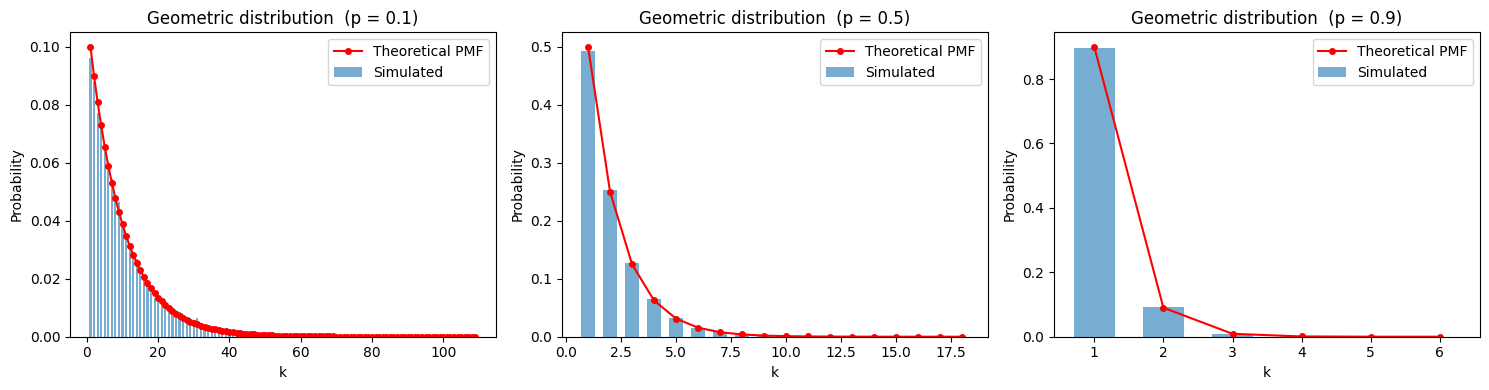

In [15]:
def plot_geometric(samples, p, ax):
    k_max = samples.max() + 1
    k = np.arange(1, k_max + 1)
    pmf = (1 - p) ** (k - 1) * p  # geometric PMF

    # Normalize histogram to probability mass (density=False, divide by n)
    counts, _ = np.histogram(samples, bins=np.arange(1, k_max + 2) - 0.5)
    ax.bar(k, counts / len(samples), width=0.6, alpha=0.6, label="Simulated")
    ax.plot(k, pmf, "ro-", markersize=4, linewidth=1.5, label="Theoretical PMF")
    ax.set_title(f"Geometric distribution  (p = {p})")
    ax.set_xlabel("k")
    ax.set_ylabel("Probability")
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (samples, p) in zip(axes, [(p01, 0.1), (p05, 0.5), (p09, 0.9)]):
    plot_geometric(samples, p, ax)

plt.tight_layout()
plt.show()


## Inverse Transform Method for Discrete Distributions

Generate $U \sim \mathcal{U}(0,1)$. Return $x_i$ whenever $F(x_{i-1}) < U \leq F(x_i)$, i.e. find the smallest $i$ such that $F(x_i) \geq U$.

In [6]:
sixPointDist = {1: 7/48, 2: 5/48, 3: 1/8, 4: 1/16, 5: 1/4, 6: 5/16}

x_vals = np.array(list(sixPointDist.keys()))
p_vals = np.array(list(sixPointDist.values()))

In [7]:
def crude_method(x, p, n):
    F = np.cumsum(p)
    U = np.random.uniform(size=n)
    indices = np.searchsorted(F, U, side="left") #search for F(x_i-1) < U < F(x_i)
    return np.array(x)[indices]

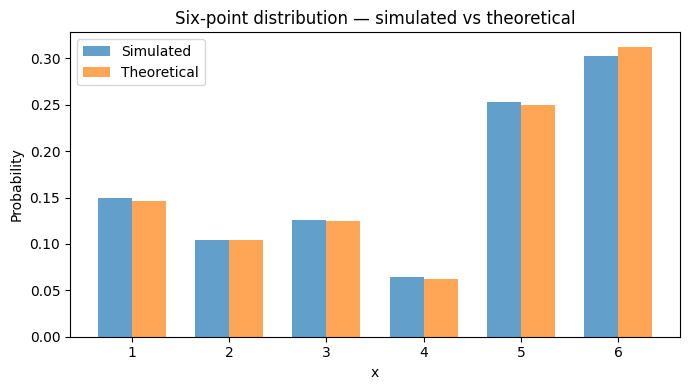

   x  Theoretical  Simulated
   1       0.1458     0.1499
   2       0.1042     0.1048
   3       0.1250     0.1255
   4       0.0625     0.0649
   5       0.2500     0.2527
   6       0.3125     0.3022


In [8]:
np.random.seed(42)

samples_6 = crude_method(x_vals, p_vals, n=10_000)

emp_pmf_6 = np.array([np.mean(samples_6 == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_6, width=width, alpha=0.7, label="Simulated")
ax.bar(x_vals + width/2, p_vals,    width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Six-point distribution — simulated vs theoretical")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'x':>4} {'Theoretical':>12} {'Simulated':>10}")
for xi, pt, ps in zip(x_vals, p_vals, emp_pmf_6):
    print(f"{xi:>4} {pt:>12.4f} {ps:>10.4f}")


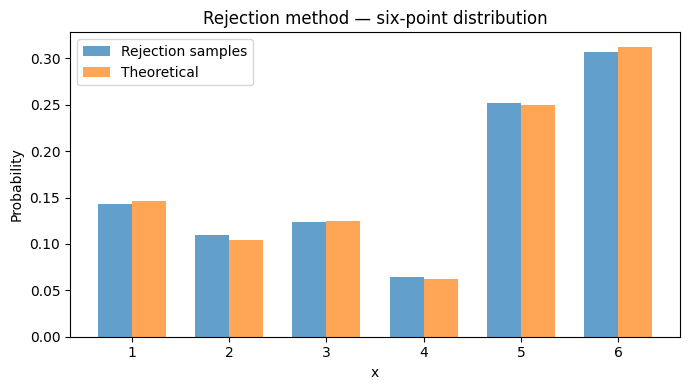

Expected trials per sample: 1.875


In [9]:
# Rejection Method
def simple_rejection_method(x, p, n):
    k = len(x)
    c = np.max(p)   # optimal: minimises expected  number of trials
    samples = []
    while len(samples) < n:
        I  = int(np.floor(k * np.random.uniform()))  # uniform index in {0,...,k-1}
        U2 = np.random.uniform()
        if U2 <= p[I] / c:
            samples.append(x[I])
    return np.array(samples)


np.random.seed(42)
samples_rej = simple_rejection_method(x_vals, p_vals, n=10_000)
emp_pmf_rej = np.array([np.mean(samples_rej == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_rej, width=width, alpha=0.7, label="Rejection samples")
ax.bar(x_vals + width/2, p_vals,      width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Rejection method — six-point distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Expected trials per sample: {len(x_vals) * np.max(p_vals):.3f}")


In [10]:
# Alias Method

def alias_setup(p):
    n = len(p)
    L = list(range(n))                           # step 1: L = {0,...,n-1}
    F = list(np.array(p, dtype=float) * n)       # step 2: F = k*p

    G = [i for i, q in enumerate(F) if q >= 1]   # step 3
    S = [i for i, q in enumerate(F) if q <= 1]   # step 3

    while S:                           # step 4: while S not empty
        i = G[0]                       # 4a
        j = S[0]                       # 4a
        L[j] = i                       # 4b
        F[i] = F[i] - (1 - F[j])       # 4b
        if F[i] < 1 - 1e-9:            # 4c
            G.pop(0)
            S.append(i)
        S.pop(0)                       # 4d

    return np.clip(F, 0, 1), np.array(L, dtype=int)


def alias_sample(x, F, L, n):
    k = len(x)
    U1 = np.random.uniform(size=n)
    U2 = np.random.uniform(size=n)
    I  = np.floor(k * U1).astype(int)      # step 1: I = floor(k*U1), 0-indexed
    picks = np.where(U2 <= F[I], I, L[I])  # step 2: if U2 <= F(I) → I, else L(I)
    return np.array(x)[picks]

Alias tables:
   i    x_i       F[i]       L[i]
   0      1     0.8750          5
   1      2     0.6250          5
   2      3     0.7500          5
   3      4     0.3750          6
   4      5     0.7500          6
   5      6     1.0000          6


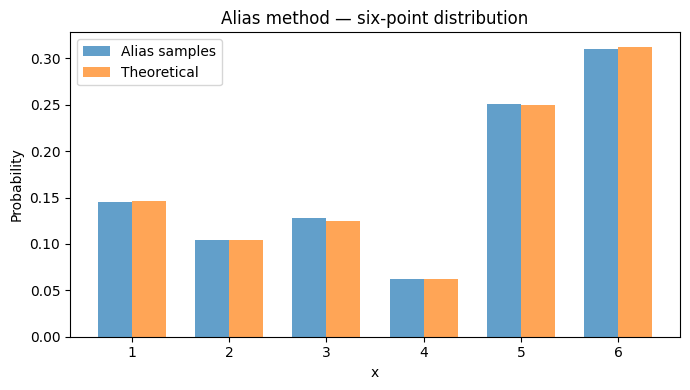

In [11]:
np.random.seed(42)

F_table, L_table = alias_setup(p_vals)

print("Alias tables:")
print(f"{'i':>4} {'x_i':>6} {'F[i]':>10} {'L[i]':>10}")
for i, (xi, f, l) in enumerate(zip(x_vals, F_table, L_table)):
    print(f"{i:>4} {xi:>6} {f:>10.4f} {x_vals[l]:>10}")

samples_alias = alias_sample(x_vals, F_table, L_table, n=10_000)
emp_pmf_alias = np.array([np.mean(samples_alias == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_alias, width=width, alpha=0.7, label="Alias samples")
ax.bar(x_vals + width/2, p_vals,        width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Alias method — six-point distribution")
ax.legend()
plt.tight_layout()
plt.show()


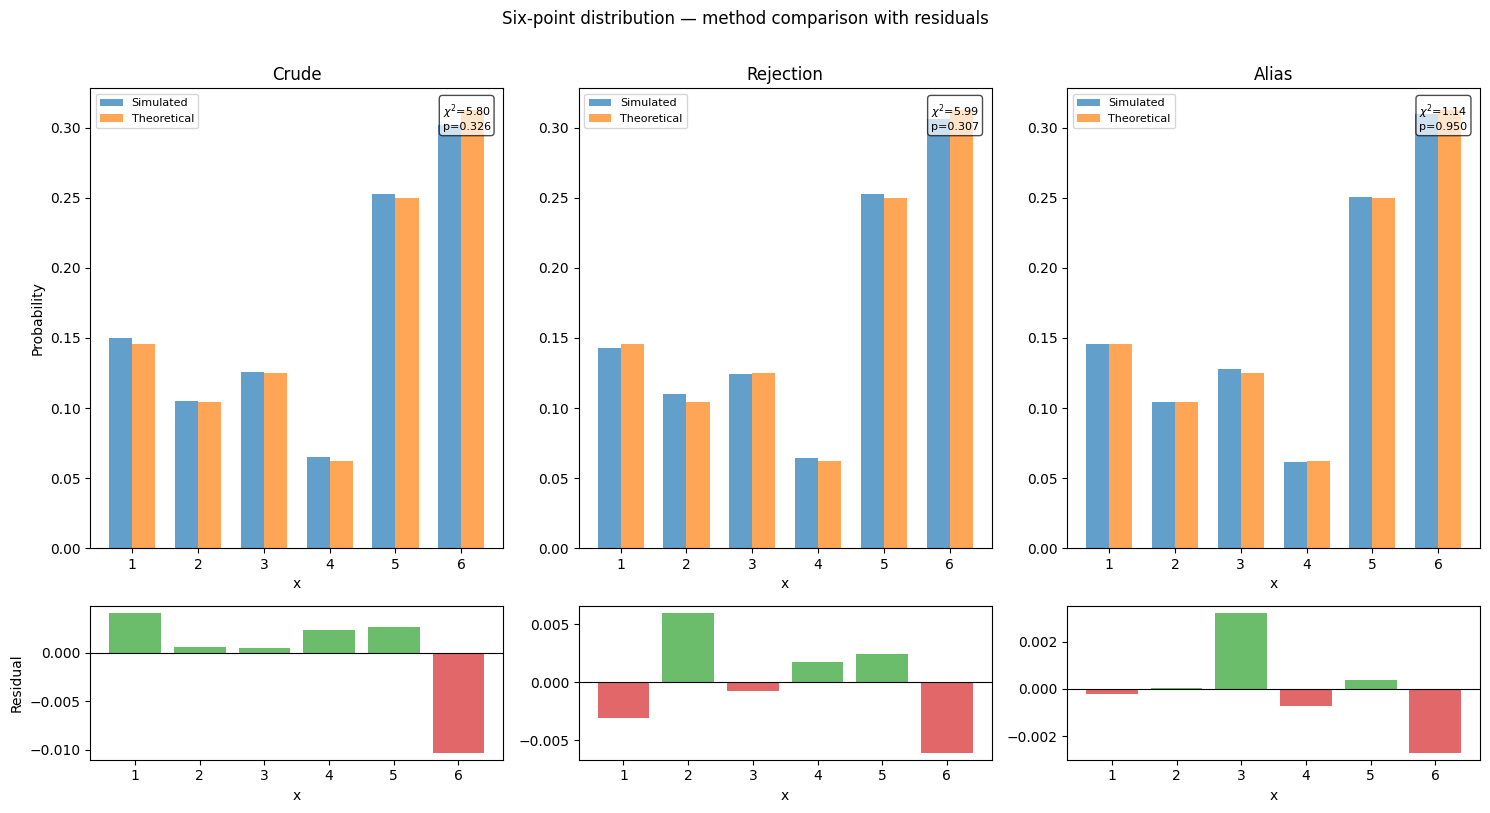

In [12]:
from scipy.stats import chisquare

N = 10_000
method_data = [
    ("Crude",     samples_6),
    ("Rejection", samples_rej),
    ("Alias",     samples_alias),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8),
                         gridspec_kw={"height_ratios": [3, 1]})

width = 0.35
for col, (title, samples) in enumerate(method_data):
    emp = np.array([np.mean(samples == xi) for xi in x_vals])

    # --- top: histogram vs theoretical ---
    ax = axes[0, col]
    ax.bar(x_vals - width/2, emp,    width=width, alpha=0.7, label="Simulated")
    ax.bar(x_vals + width/2, p_vals, width=width, alpha=0.7, label="Theoretical")
    ax.set_title(title)
    ax.set_xticks(x_vals)
    ax.set_xlabel("x")
    ax.legend(fontsize=8)

    # chi-squared test
    obs = np.array([np.sum(samples == xi) for xi in x_vals])
    exp = p_vals * N
    stat, pval = chisquare(obs, exp)
    ax.text(0.97, 0.97, f"$\\chi^2$={stat:.2f}\np={pval:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))

    # --- bottom: residuals (emp - theoretical) ---
    ax2 = axes[1, col]
    residuals = emp - p_vals
    colors = ["tab:green" if r >= 0 else "tab:red" for r in residuals]
    ax2.bar(x_vals, residuals, color=colors, alpha=0.7)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xticks(x_vals)
    ax2.set_xlabel("x")
    ax2.set_ylabel("Residual" if col == 0 else "")

axes[0, 0].set_ylabel("Probability")
plt.suptitle("Six-point distribution — method comparison with residuals", y=1.01)
plt.tight_layout()
plt.show()


## Part 3 - Performance Comparison

In [13]:
import time
from scipy.stats import chisquare

N    = 10_000
REPS = 50
np.random.seed(0)

F_table, L_table = alias_setup(p_vals)

def time_method(fn, reps=REPS):
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    return (time.perf_counter() - t0) / reps * 1e3  # ms

np.random.seed(42)
s_crude  = crude_method(x_vals, p_vals, N)
s_reject = simple_rejection_method(x_vals, p_vals, N)
s_alias  = alias_sample(x_vals, F_table, L_table, N)

t_crude  = time_method(lambda: crude_method(x_vals, p_vals, N))
t_reject = time_method(lambda: simple_rejection_method(x_vals, p_vals, N))
t_alias  = time_method(lambda: alias_sample(x_vals, F_table, L_table, N))

def chi2_result(samples):
    obs = np.array([np.sum(samples == xi) for xi in x_vals])
    stat, pval = chisquare(obs, p_vals * N)
    return stat, pval

chi_crude  = chi2_result(s_crude)
chi_reject = chi2_result(s_reject)
chi_alias  = chi2_result(s_alias)

print(f"{'Method':<20} {'Time (ms)':>10} {'χ² stat':>10} {'p-value':>10}  {'Reject H0?':>12}")
print("-" * 68)
for name, t, (stat, pval) in [
    ("Crude",     t_crude,  chi_crude),
    ("Rejection", t_reject, chi_reject),
    ("Alias",     t_alias,  chi_alias),
]:
    reject = "Yes" if pval < 0.05 else "No"
    print(f"{name:<20} {t:>10.2f} {stat:>10.3f} {pval:>10.4f}  {reject:>12}")

print(f"\nχ² critical value (df={len(x_vals)-1}, α=0.05): {5:.3f}  [scipy: {chisquare([1]*6,[1]*6)[0]:.0f}]")
print(f"H0: samples follow the theoretical distribution.")
print(f"Fail to reject H0 (p > 0.05) → method produces the correct distribution.")

k = len(x_vals)
c = np.max(p_vals)
print(f"\nRejection — expected trials per sample: k·c = {k}·{c:.4f} = {k*c:.3f}")


Method                Time (ms)    χ² stat    p-value    Reject H0?
--------------------------------------------------------------------
Crude                      1.00      5.801     0.3261            No
Rejection                268.16      3.134     0.6793            No
Alias                      0.66      0.917     0.9690            No

χ² critical value (df=5, α=0.05): 5.000  [scipy: 0]
H0: samples follow the theoretical distribution.
Fail to reject H0 (p > 0.05) → method produces the correct distribution.

Rejection — expected trials per sample: k·c = 6·0.3125 = 1.875


## Part 4 - Recommendations

### Crude Method
**How it works:** Build the CDF, draw $U \sim \mathcal{U}(0,1)$, return $x_i$ at the first CDF step that exceeds $U$.

| | |
|---|---|
| **Speed** | $O(\log k)$ per sample (binary search). Fast for small $k$; slows as $k$ grows. |
| **Setup** | $O(k)$ — just `cumsum`. Negligible. |
| **Memory** | $O(k)$ for the CDF array. |

**Use when:** $k$ is small-to-moderate, the distribution changes between batches (no amortisation of setup), or simplicity is the priority.

---

### Rejection Method
**How it works:** Draw a candidate index $I$ uniformly, accept with probability $p_I / c$; repeat until accepted.

| | |
|---|---|
| **Speed** | Expected $k \cdot c$ trials per sample. With $c = \max(p_i)$, cost grows when one $p_i \gg$ others. |
| **Setup** | $O(1)$ — just compute $c = \max(p)$. |
| **Memory** | $O(1)$ extra — only needs the $p$ array. |

**Use when:** $k$ is small and probabilities are roughly uniform (low rejection rate). **Avoid** when one probability dominates — a high $c$ means many rejections and poor efficiency.

---

### Alias Method
**How it works:** Pre-process $p$ into tables $F$ and $L$ of size $k$. Each sample needs exactly two uniforms and one comparison — $O(1)$.

| | |
|---|---|
| **Speed** | $O(1)$ per sample after setup. Fully vectorisable — fastest for large $N$. |
| **Setup** | $O(k)$ — build $F$ and $L$ tables once. |
| **Memory** | $O(k)$ for $F$ and $L$. |

**Use when:** generating a very large number of samples from a fixed distribution. The $O(k)$ setup cost is quickly amortised — the alias method is the standard choice in high-performance simulation.

---

### Summary table

| Criterion | Crude | Rejection | Alias |
|---|:---:|:---:|:---:|
| Per-sample cost | $O(\log k)$ | $O(k \cdot c)$ variable | $O(1)$ |
| Setup cost | $O(k)$ | $O(1)$ | $O(k)$ |
| Memory | $O(k)$ | $O(1)$ | $O(k)$ |